In [4]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBRegressor

# V4 MODEL TUNING
# V4 = robust V3 features + hyperparameter optimization
# Linear Regression = reference model
# RF/XGB = tuned models

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

FINAL_DIR = ROOT / "data" / "final"
RESULTS_DIR = ROOT / "outputs" / "results"
MODELS_DIR = ROOT / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(FINAL_DIR / "ml_ready_player_games_v3.parquet")
df["game_date"] = pd.to_datetime(df["game_date"])

train_df = df[df["season"] == "2023-24"].sort_values("game_date").reset_index(drop=True)
test_df = df[df["season"] == "2024-25"].sort_values("game_date").reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

targets = ["target_pts", "target_reb", "target_ast"]

# Remove targets + raw post-game result columns to avoid leakage
drop_cols = {
    "target_pts", "target_reb", "target_ast",
    "pts", "reb", "ast", "min",
    "fgm", "fga", "fg3m", "fg3a",
    "ftm", "fta", "oreb", "dreb",
    "stl", "blk", "tov", "pf",
    "plus_minus", "wl",
    "game_id", "player_name", "game_date", "season"
}

feature_cols = [c for c in df.columns if c not in drop_cols]

categorical_cols = train_df[feature_cols].select_dtypes(include=["object","category"]).columns.tolist()
numeric_cols = train_df[feature_cols].select_dtypes(exclude=["object","category"]).columns.tolist()
print("Categorical:", categorical_cols)
print("Numerical:", len(numeric_cols))

print("Feature count:", len(feature_cols))
print("Numeric features:", len(numeric_cols))
print("Categorical features:", categorical_cols)

def build_preprocessor(scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipe = Pipeline(numeric_steps)

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols)
    ])

def build_pipeline(model, scale_numeric=False):
    return Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=scale_numeric)),
        ("model", model)
    ])

# Temporal validation inside 2023-24 training season
# First 80% = train, last 20% = validation for tuning
split_idx = int(len(train_df) * 0.8)
test_fold = np.full(len(train_df), -1)
test_fold[split_idx:] = 0
temporal_cv = PredefinedSplit(test_fold)

all_results = []
all_predictions = []

def evaluate_model(pipe, target, model_name, tuned=False, best_params=None):
    start = time.time()

    X_train = train_df[feature_cols]
    y_train = train_df[target]

    X_test = test_df[feature_cols]
    y_test = test_df[target]

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    run_id = f"V4_{target}_{model_name}"

    result = {
        "run_id": run_id,
        "version": "V4",
        "target": target,
        "model": model_name,
        "tuned": tuned,
        "mae": mae,
        "rmse": rmse,
        "feature_count": len(feature_cols),
        "runtime_seconds": time.time() - start,
        "best_params": json.dumps(best_params) if best_params else ""
    }

    pred_cols = [
        c for c in [
            "player_id", "player_name", "team_abbr",
            "opponent_team", "game_id", "game_date",
            "season", "home_away"
        ]
        if c in test_df.columns
    ]

    pred_df = test_df[pred_cols].copy()
    pred_df["target"] = target
    pred_df["actual"] = y_test.values
    pred_df["prediction"] = preds
    pred_df["error"] = pred_df["prediction"] - pred_df["actual"]
    pred_df["abs_error"] = pred_df["error"].abs()
    pred_df["squared_error"] = pred_df["error"] ** 2
    pred_df["version"] = "V4"
    pred_df["model"] = model_name
    pred_df["tuned"] = tuned
    pred_df["run_id"] = run_id

    all_results.append(result)
    all_predictions.append(pred_df)

    print(f"{run_id}: MAE={mae:.4f}, RMSE={rmse:.4f}")

    return pipe

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

xgb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.9, 1.0],
    "model__reg_alpha": [0, 0.1, 1.0],
    "model__reg_lambda": [1, 5, 10]
}

for target in targets:
    print("\n" + "=" * 70)
    print(f"Target: {target}")
    print("=" * 70)

    X_train = train_df[feature_cols]
    y_train = train_df[target]

    # Linear Regression Reference
    print("\nTraining Linear Regression reference...")

    lr_pipe = build_pipeline(
        LinearRegression(),
        scale_numeric=True
    )

    lr_pipe = evaluate_model(
        pipe=lr_pipe,
        target=target,
        model_name="LinearRegression",
        tuned=False,
        best_params=None
    )

    joblib.dump(lr_pipe, MODELS_DIR / f"linear_regression_v4_{target}.pkl")

    # Random Forest Tuning
    print("\nTuning Random Forest...")

    rf_pipe = build_pipeline(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        scale_numeric=False
    )

    rf_search = RandomizedSearchCV(
        estimator=rf_pipe,
        param_distributions=rf_param_grid,
        n_iter=12,
        scoring="neg_mean_absolute_error",
        cv=temporal_cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    rf_search.fit(X_train, y_train)

    print("Best RF params:", rf_search.best_params_)

    best_rf_pipe = evaluate_model(
        pipe=rf_search.best_estimator_,
        target=target,
        model_name="RandomForestRegressor",
        tuned=True,
        best_params=rf_search.best_params_
    )

    joblib.dump(best_rf_pipe, MODELS_DIR / f"random_forest_v4_{target}.pkl")

    # XGBoost Tuning
    print("\nTuning XGBoost...")

    xgb_pipe = build_pipeline(
        XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=4
        ),
        scale_numeric=False
    )

    xgb_search = RandomizedSearchCV(
        estimator=xgb_pipe,
        param_distributions=xgb_param_grid,
        n_iter=15,
        scoring="neg_mean_absolute_error",
        cv=temporal_cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    xgb_search.fit(X_train, y_train)

    print("Best XGB params:", xgb_search.best_params_)

    best_xgb_pipe = evaluate_model(
        pipe=xgb_search.best_estimator_,
        target=target,
        model_name="XGBRegressor",
        tuned=True,
        best_params=xgb_search.best_params_
    )

    joblib.dump(best_xgb_pipe, MODELS_DIR / f"xgboost_v4_{target}.pkl")

# Save Results

results_df = pd.DataFrame(all_results)
predictions_df = pd.concat(all_predictions, ignore_index=True)

results_df.to_csv(RESULTS_DIR / "v4_model_tuning_results.csv", index=False)
predictions_df.to_parquet(RESULTS_DIR / "v4_predictions.parquet", index=False)

best_by_target = (
    results_df.sort_values("mae")
    .groupby("target")
    .head(1)
    .reset_index(drop=True)
)

best_by_target.to_csv(RESULTS_DIR / "v4_best_models_by_target.csv", index=False)

summary = {
    "version": "V4",
    "description": "V3 context features with tuned Random Forest/XGBoost and Linear Regression reference.",
    "train_season": "2023-24",
    "test_season": "2024-25",
    "feature_count": len(feature_cols),
    "targets": targets,
    "best_models_by_target": best_by_target.to_dict(orient="records")
}

with open(RESULTS_DIR / "v4_tuning_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\nV4 tuning complete.")
print("\nAll results:")
display(results_df.sort_values(["target", "mae"]))

print("\nBest models by target:")
display(best_by_target)

Train shape: (26401, 92)
Test shape: (26306, 92)
Categorical: ['team_abbr', 'home_away', 'opponent_team']
Numerical: 75
Feature count: 78
Numeric features: 75
Categorical features: ['team_abbr', 'home_away', 'opponent_team']

Target: target_pts

Training Linear Regression reference...


C:\Users\aruls\AppData\Local\Temp\ipykernel_29884\1853218148.py:59: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df[feature_cols].select_dtypes(include=["object","category"]).columns.tolist()


V4_target_pts_LinearRegression: MAE=2.9467, RMSE=3.9471

Tuning Random Forest...
Fitting 1 folds for each of 12 candidates, totalling 12 fits
Best RF params: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 16}
V4_target_pts_RandomForestRegressor: MAE=2.4576, RMSE=3.3878

Tuning XGBoost...
Fitting 1 folds for each of 15 candidates, totalling 15 fits
Best XGB params: {'model__subsample': 1.0, 'model__reg_lambda': 1, 'model__reg_alpha': 0, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
V4_target_pts_XGBRegressor: MAE=2.1953, RMSE=3.0124

Target: target_reb

Training Linear Regression reference...
V4_target_reb_LinearRegression: MAE=1.2506, RMSE=1.6918

Tuning Random Forest...
Fitting 1 folds for each of 12 candidates, totalling 12 fits
Best RF params: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf'

,run_id,version,target,model,tuned,mae,rmse,feature_count,runtime_seconds,best_params
8,V4_target_ast_XGBRegressor,V4,target_ast,XGBRegressor,True,0.602005,0.886846,78,3.015445,"{""model__subsample"": 1.0, ""model__reg_lambda"":..."
7,V4_target_ast_RandomForestRegressor,V4,target_ast,RandomForestRegressor,True,0.680376,1.002479,78,16.090809,"{""model__n_estimators"": 100, ""model__min_sampl..."
6,V4_target_ast_LinearRegression,V4,target_ast,LinearRegression,False,0.845995,1.193216,78,0.499265,
2,V4_target_pts_XGBRegressor,V4,target_pts,XGBRegressor,True,2.195287,3.012371,78,2.848763,"{""model__subsample"": 1.0, ""model__reg_lambda"":..."
1,V4_target_pts_RandomForestRegressor,V4,target_pts,RandomForestRegressor,True,2.457605,3.387816,78,19.421061,"{""model__n_estimators"": 100, ""model__min_sampl..."
0,V4_target_pts_LinearRegression,V4,target_pts,LinearRegression,False,2.946712,3.947072,78,0.528625,
5,V4_target_reb_XGBRegressor,V4,target_reb,XGBRegressor,True,0.908092,1.257660,78,3.174390,"{""model__subsample"": 1.0, ""model__reg_lambda"":..."
4,V4_target_reb_RandomForestRegressor,V4,target_reb,RandomForestRegressor,True,1.014672,1.404213,78,19.811197,"{""model__n_estimators"": 100, ""model__min_sampl..."
3,V4_target_reb_LinearRegression,V4,target_reb,LinearRegression,False,1.250617,1.691776,78,0.491760,



Best models by target:


,run_id,version,target,model,tuned,mae,rmse,feature_count,runtime_seconds,best_params
0,V4_target_ast_XGBRegressor,V4,target_ast,XGBRegressor,True,0.602005,0.886846,78,3.015445,"{""model__subsample"": 1.0, ""model__reg_lambda"":..."
1,V4_target_reb_XGBRegressor,V4,target_reb,XGBRegressor,True,0.908092,1.257660,78,3.174390,"{""model__subsample"": 1.0, ""model__reg_lambda"":..."
2,V4_target_pts_XGBRegressor,V4,target_pts,XGBRegressor,True,2.195287,3.012371,78,2.848763,"{""model__subsample"": 1.0, ""model__reg_lambda"":..."


In [5]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

df = pd.read_parquet(ROOT / "data" / "final" / "ml_ready_player_games_v3.parquet")

possible_leakage = [
    c for c in df.columns
    if c.lower() in [
        "pts", "reb", "ast", "min", "fgm", "fga", "fg3m", "fg3a",
        "ftm", "fta", "oreb", "dreb", "stl", "blk", "tov", "pf",
        "plus_minus", "wl"
    ]
]

target_cols = ["target_pts", "target_reb", "target_ast"]

print("Possible raw post-game leakage columns present:")
print(possible_leakage)

print("\nTarget columns:")
print([c for c in target_cols if c in df.columns])

print("\nColumns containing suspicious words:")
suspicious = [
    c for c in df.columns
    if any(word in c.lower() for word in ["actual", "target", "result", "post", "final"])
]
print(suspicious)

Possible raw post-game leakage columns present:
['min', 'fga', 'fg3a', 'fta', 'pts', 'reb', 'ast']

Target columns:
['target_pts', 'target_reb', 'target_ast']

Columns containing suspicious words:
['target_pts', 'target_reb', 'target_ast', 'post_l5_pts', 'post_l10_pts', 'post_l5_reb', 'post_l10_reb', 'post_l5_ast', 'post_l10_ast', 'post_l5_min', 'post_l10_min', 'post_l5_fga', 'post_l10_fga', 'post_l5_fg3a', 'post_l10_fg3a', 'post_l5_fta', 'post_l10_fta']


In [7]:
drop_cols = {
    "target_pts", "target_reb", "target_ast",
    "pts", "reb", "ast", "min",
    "fgm", "fga", "fg3m", "fg3a",
    "ftm", "fta", "oreb", "dreb",
    "stl", "blk", "tov", "pf",
    "plus_minus", "wl",
    "game_id", "player_name", "game_date",
    "season"
}

feature_cols = [c for c in df.columns if c not in drop_cols]

bad_used = [c for c in feature_cols if c in possible_leakage or "target" in c.lower()]

print("Leakage columns accidentally used in V4:")
print(bad_used)

print("\nFeature count:", len(feature_cols))

Leakage columns accidentally used in V4:
[]

Feature count: 78


,version,Linear Regression,Random Forest,XGBoost
0,Baseline,4.749000,5.108000,4.760000
1,V0,4.654000,4.768000,4.689000
2,V1,4.640000,4.716000,4.679000
3,V2,4.614000,4.671000,4.611000
4,V4,2.946712,2.457605,2.195287


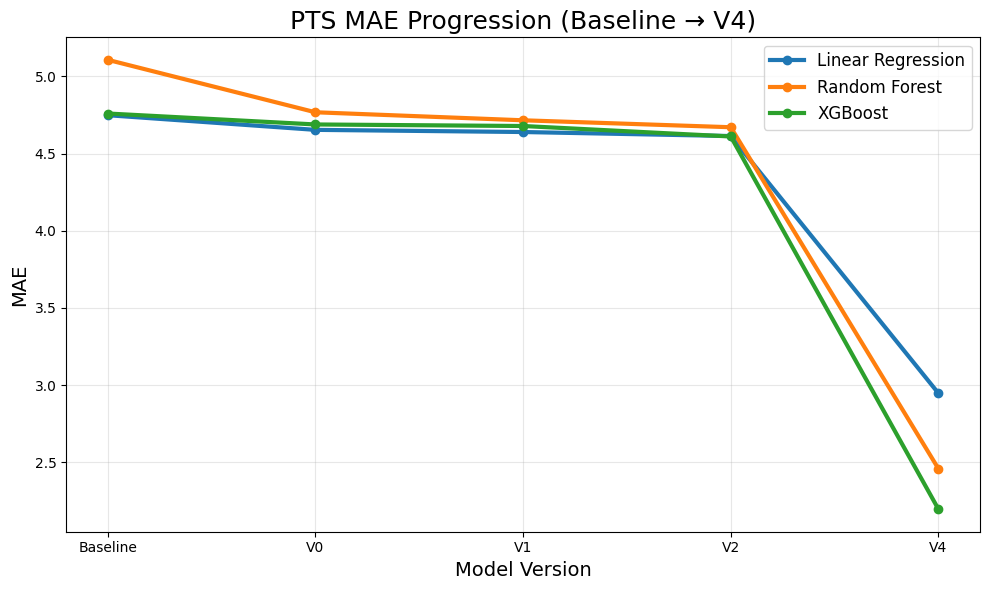

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(r"C:\Users\aruls\anaconda_projects\analytics\NBACapstone-main")
RESULTS_DIR = ROOT / "outputs" / "results"
FIGURES_DIR = ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Manual values from Notebook 3 screenshot
old_pts = pd.DataFrame({
    "version": ["Baseline", "V0", "V1", "V2"],
    "Linear Regression": [4.749, 4.654, 4.640, 4.614],
    "Random Forest": [5.108, 4.768, 4.716, 4.671],
    "XGBoost": [4.760, 4.689, 4.679, 4.611],
})

# Import real V4 results
v4 = pd.read_csv(RESULTS_DIR / "v4_model_tuning_results.csv")

v4_pts = v4[v4["target"] == "target_pts"].copy()

model_map = {
    "LinearRegression": "Linear Regression",
    "RandomForestRegressor": "Random Forest",
    "XGBRegressor": "XGBoost"
}

v4_row = {"version": "V4"}

for raw_model, clean_model in model_map.items():
    val = v4_pts.loc[v4_pts["model"] == raw_model, "mae"].iloc[0]
    v4_row[clean_model] = val

progression_pts = pd.concat(
    [old_pts, pd.DataFrame([v4_row])],
    ignore_index=True
)

display(progression_pts)

plt.figure(figsize=(10, 6))

for model in ["Linear Regression", "Random Forest", "XGBoost"]:
    plt.plot(
        progression_pts["version"],
        progression_pts[model],
        marker="o",
        linewidth=3,
        label=model
    )

plt.title("PTS MAE Progression (Baseline → V4)", fontsize=18)
plt.xlabel("Model Version", fontsize=14)
plt.ylabel("MAE", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "final_pts_mae_progression.png", dpi=300)
plt.show()

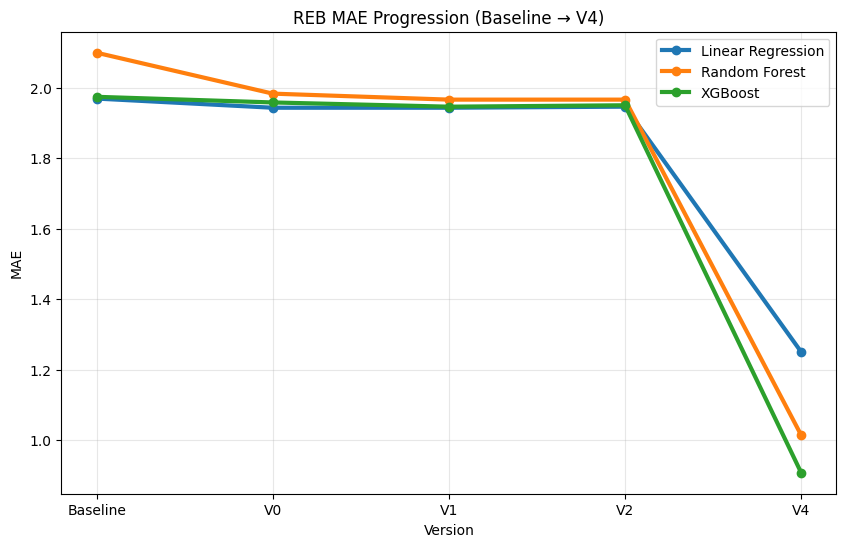

In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(r"C:\Users\aruls\anaconda_projects\analytics\NBACapstone-main")
RESULTS_DIR = ROOT / "outputs" / "results"

v4 = pd.read_csv(RESULTS_DIR / "v4_model_tuning_results.csv")

v4_reb = v4[v4["target"] == "target_reb"]

model_map = {
    "LinearRegression": "Linear Regression",
    "RandomForestRegressor": "Random Forest",
    "XGBRegressor": "XGBoost"
}

v4_row = {"version": "V4"}
for raw, clean in model_map.items():
    val = v4_reb.loc[v4_reb["model"] == raw, "mae"].iloc[0]
    v4_row[clean] = val

# checkpoint values (ONLY manual part)
reb_df = pd.DataFrame({
    "version": ["Baseline", "V0", "V1", "V2"],
    "Linear Regression": [1.969, 1.943, 1.943, 1.946],
    "Random Forest": [2.099, 1.983, 1.966, 1.966],
    "XGBoost": [1.974, 1.958, 1.946, 1.950],
})

reb_df = pd.concat([reb_df, pd.DataFrame([v4_row])])

plt.figure(figsize=(10,6))
for model in ["Linear Regression", "Random Forest", "XGBoost"]:
    plt.plot(reb_df["version"], reb_df[model], marker="o", linewidth=3, label=model)

plt.title("REB MAE Progression (Baseline → V4)")
plt.xlabel("Version")
plt.ylabel("MAE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

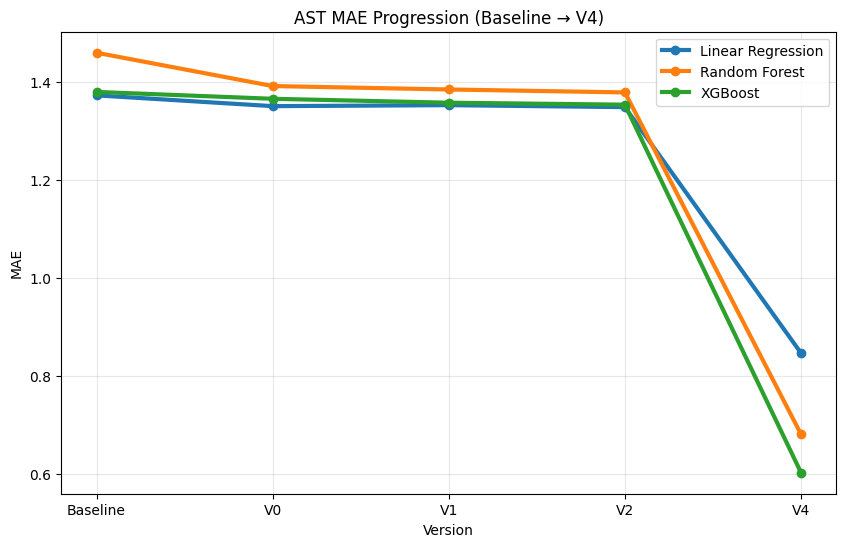

In [15]:
v4_ast = v4[v4["target"] == "target_ast"]

v4_row = {"version": "V4"}
for raw, clean in model_map.items():
    val = v4_ast.loc[v4_ast["model"] == raw, "mae"].iloc[0]
    v4_row[clean] = val

ast_df = pd.DataFrame({
    "version": ["Baseline", "V0", "V1", "V2"],
    "Linear Regression": [1.372, 1.350, 1.352, 1.348],
    "Random Forest": [1.459, 1.391, 1.384, 1.378],
    "XGBoost": [1.379, 1.365, 1.357, 1.353],
})

ast_df = pd.concat([ast_df, pd.DataFrame([v4_row])])

plt.figure(figsize=(10,6))
for model in ["Linear Regression", "Random Forest", "XGBoost"]:
    plt.plot(ast_df["version"], ast_df[model], marker="o", linewidth=3, label=model)

plt.title("AST MAE Progression (Baseline → V4)")
plt.xlabel("Version")
plt.ylabel("MAE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()